Documentation: https://keypoint-moseq.readthedocs.io/en/latest/modeling.html

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "36"
os.environ["MKL_NUM_THREADS"] = "36"
os.environ["OPENBLAS_NUM_THREADS"] = "36"
os.environ["NUMEXPR_NUM_THREADS"] = "36"
os.environ["XLA_FLAGS"] = (
    "--xla_cpu_multi_thread_eigen=true "
)


import keypoint_moseq as kpms
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import yaml

print("XLA_FLAGS:", os.environ.get("XLA_FLAGS"))
print("OMP_NUM_THREADS:", os.environ.get("OMP_NUM_THREADS"))

MULTI_ANIMAL = False

XLA_FLAGS: --xla_cpu_multi_thread_eigen=true 
OMP_NUM_THREADS: 36


## Setting up the data. Videography data from the final day of the adaptive mice (Agg and NonAgg) and from Day 05 (the last day of the first week) of the maladaptive mice were used to tune the hyperparameters and train the KeypointMoSeq model

In [2]:
dlc_config_file = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC\trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03\config.yaml"

if MULTI_ANIMAL:
    kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS_multiAnimal"
else: 
    kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS"

kpms.setup_project(kpmoseq_dir, deeplabcut_config=dlc_config_file, overwrite = False)

config = lambda: kpms.load_config(kpmoseq_dir)

The directory `C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\t
rainingSessions\trainingSessions_topView_KPMS` already exists. Use
`overwrite=True` or pick a different name


In [32]:
dlc_videos_path = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions")

pcutoff = 0.8
dlc_folders_dataset = [str(f) for f in dlc_videos_path.rglob(rf"*{pcutoff}_skeleton\*snapshot_best-100_sk.h5")]
#np.save(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\filesUsed_forTraining", dlc_folders)

dlc_folders_train = list(np.load(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\filesUsed_forTraining.npy"))

In [33]:
if MULTI_ANIMAL:
    exclude = ["single"]
else:
    exclude = ["Intruder","single"]

raw_coordinates, raw_confidences, _ = kpms.load_keypoints(dlc_folders_train, "deeplabcut", exclude_individuals=exclude)

Loading keypoints:  15%|██▌              | 4/27 [00:00<00:01, 14.42it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:  30%|█████            | 8/27 [00:00<00:01, 15.41it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:  44%|███████         | 12/27 [00:00<00:00, 15.75it/s]

...

Loading keypoints:  81%|█████████████   | 22/27 [00:01<00:00, 15.31it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints: 100%|████████████████| 27/27 [00:01<00:00, 15.21it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.




Coordinates for the following bodyparts are missing (set to NaN) in at least 50.0% of frames:
 - leftEar

This may cause problems during modeling. See https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#high-proportion-of-nans for additional information.

In [34]:
# For some reason, bodyparts returned from kpms.load_keypoints is of type "set", not "list". This means that bodypart label's order is not aligned anymore with the other variables 

with open(dlc_config_file, "r") as f:
        dlcConfig = yaml.safe_load(f)

bodyparts = dlcConfig["multianimalbodyparts"]

In [35]:
for key, value in raw_coordinates.items():
    kpms.check_nan_proportions({key: value}, list(bodyparts), breakdown=True)

Styler.applymap has been deprecated. Use Styler.map instead.

,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse975826_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.462980,0.024293,0.025656,0.055507,0.005915,0.005528,0.010172,0.036866,0.065061,0.110132


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse975827_Day17_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.527629,0.007510,0.006738,0.032212,0.000177,0.000080,0.000273,0.001544,0.005838,0.018494


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse975830_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.513986,0.006200,0.003901,0.035369,0.001295,0.000049,0.001878,0.004727,0.014989,0.032147


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse975833_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.445265,0.015426,0.008304,0.036032,0.001360,0.000534,0.003286,0.009663,0.022435,0.047476


...

,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse978528_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.637366,0.008936,0.008704,0.035745,0.001777,0.001329,0.002276,0.007275,0.013454,0.037605


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse1010832_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.730426,0.007510,0.006921,0.019128,0.001113,0.000998,0.001996,0.005792,0.013385,0.051248


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse1013590_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.602160,0.005940,0.004107,0.034165,0.001031,0.001325,0.001833,0.005760,0.010014,0.040759


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse1034805_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.613207,0.005488,0.005260,0.045485,0.001515,0.000668,0.001189,0.005146,0.008078,0.030877


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse1034814_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.734610,0.020878,0.025568,0.032425,0.001645,0.001287,0.002703,0.015667,0.038271,0.061315


In [36]:
kpms.update_config(kpmoseq_dir, fps=50, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    raw_coordinates,
    raw_confidences,
    kpmoseq_dir,
    overwrite=False,
    **config()
)

In [37]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

In [38]:
#%matplotlib widget
#kpms.noise_calibration(kpmoseq_dir, coordinates, confidences, **config())

## Extracting the number of components from videography data that explain >= 90% of the variance in behavioral syllables

>=90.0% of variance exlained by 5 components.


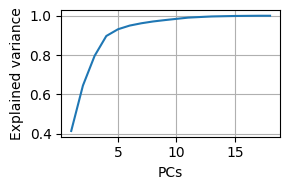

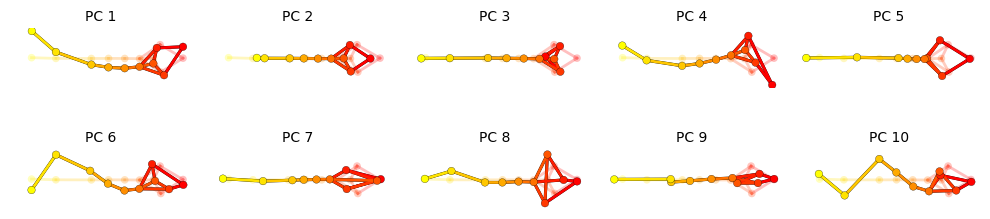

In [67]:
plt.close("all")
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, kpmoseq_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=kpmoseq_dir)
kpms.plot_pcs(pca, project_dir=kpmoseq_dir, **config())

In [68]:
kpms.update_config(kpmoseq_dir, latent_dim=5) # >= 90.0% of the variance is explained by 6 components

In [69]:
kpms.update_config(
    kpmoseq_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

## **Kappa scan**: Hyperparameter that that determines the rate of transitions between syllables. Higher values of kappa lead to longer syllables and smaller values lead to shorter syllables.

Fitting model with kappa=1000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000.0


 49%|█████████████████▏                 | 25/51 [07:24<07:20, 16.93s/it]

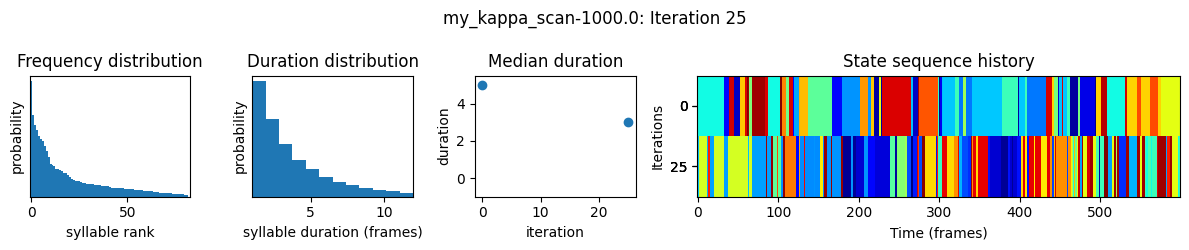

 98%|██████████████████████████████████▎| 50/51 [14:26<00:16, 16.82s/it]

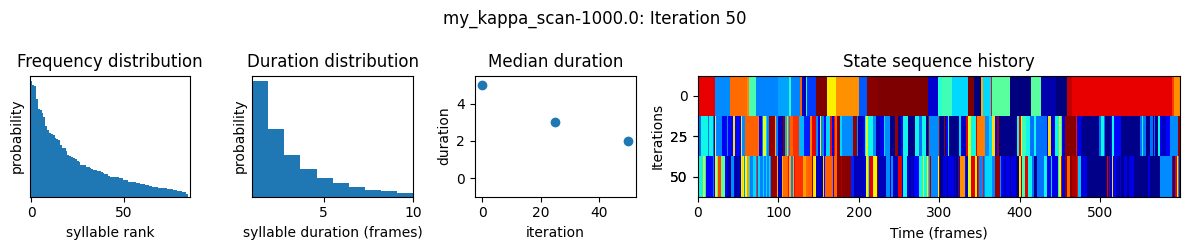

100%|███████████████████████████████████| 51/51 [14:45<00:00, 17.35s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000.0


 49%|██████████████▋               | 25/51 [1:26:18<1:29:55, 207.50s/it]

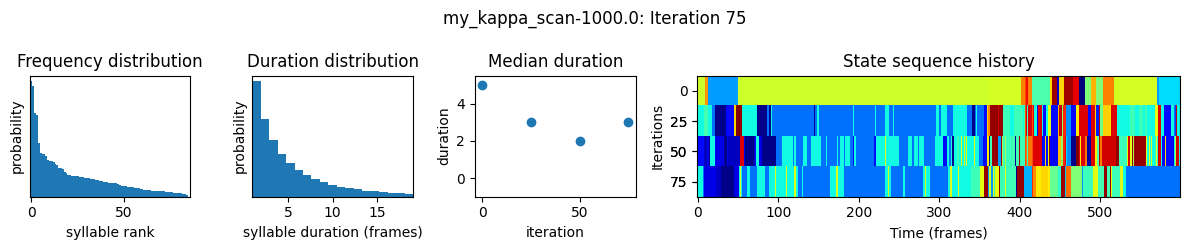

 98%|███████████████████████████████▎| 50/51 [2:52:26<03:26, 206.76s/it]

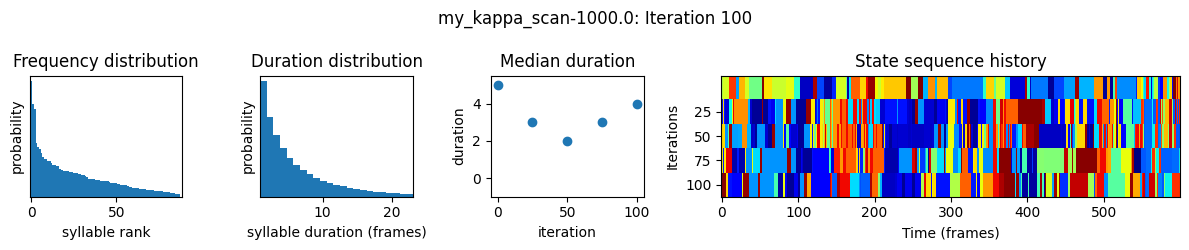

100%|████████████████████████████████| 51/51 [2:55:56<00:00, 206.99s/it]


Fitting model with kappa=10000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000.0


 49%|█████████████████▏                 | 25/51 [07:19<07:37, 17.58s/it]

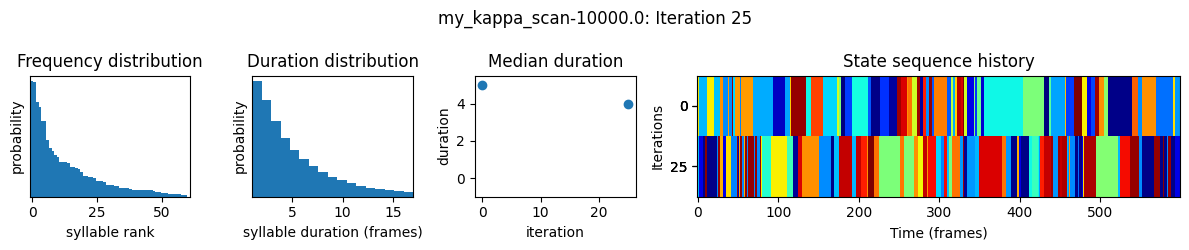

 98%|██████████████████████████████████▎| 50/51 [14:27<00:17, 17.05s/it]

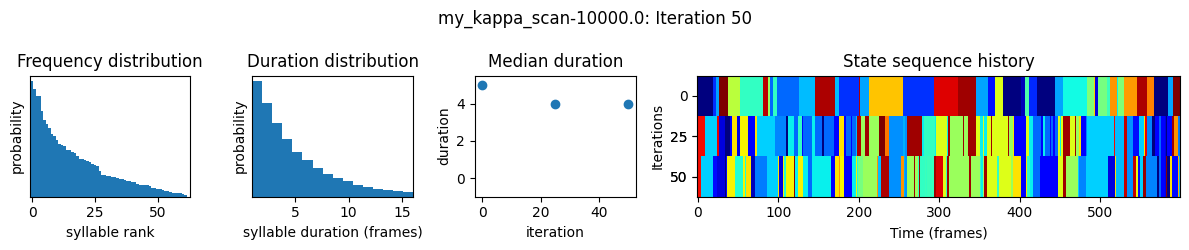

100%|███████████████████████████████████| 51/51 [14:45<00:00, 17.36s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000.0


 49%|██████████████▋               | 25/51 [1:26:16<1:29:54, 207.49s/it]

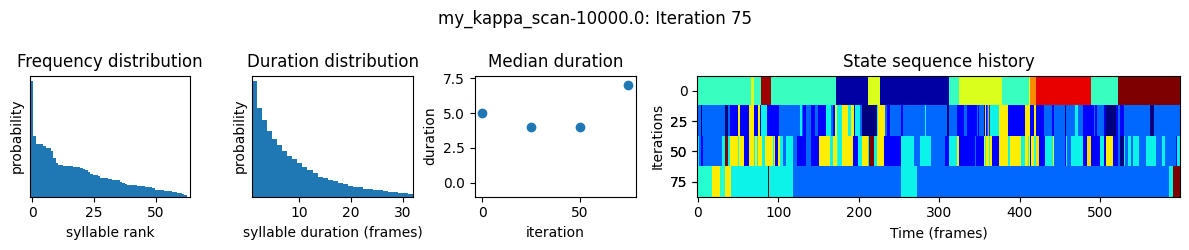

 98%|███████████████████████████████▎| 50/51 [2:52:37<03:26, 207.00s/it]

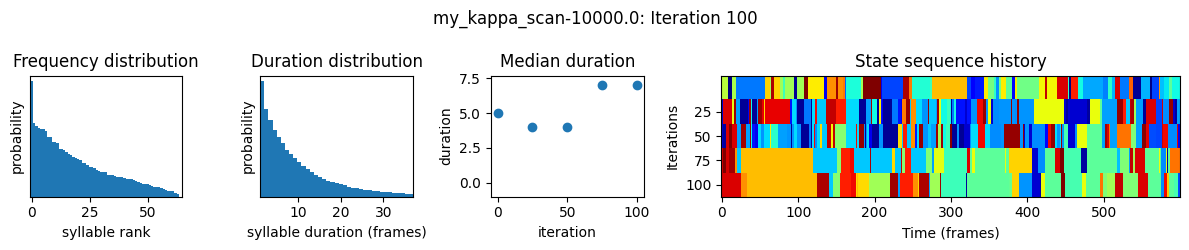

100%|████████████████████████████████| 51/51 [2:56:06<00:00, 207.18s/it]


Fitting model with kappa=100000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000.0


 49%|█████████████████▏                 | 25/51 [06:40<06:50, 15.79s/it]

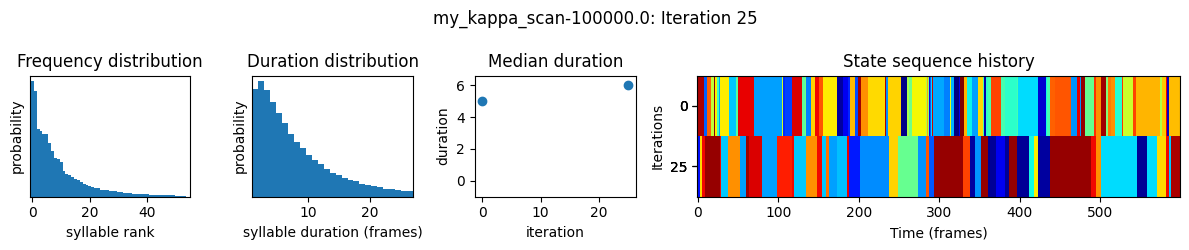

 98%|██████████████████████████████████▎| 50/51 [13:18<00:15, 15.90s/it]

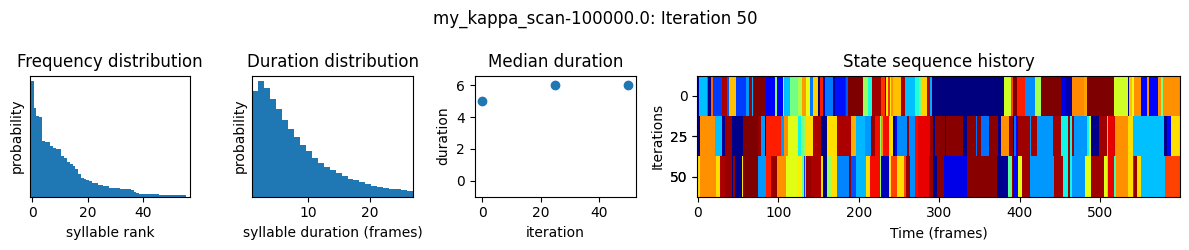

100%|███████████████████████████████████| 51/51 [13:36<00:00, 16.00s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000.0


 49%|██████████████▋               | 25/51 [1:25:15<1:29:49, 207.29s/it]

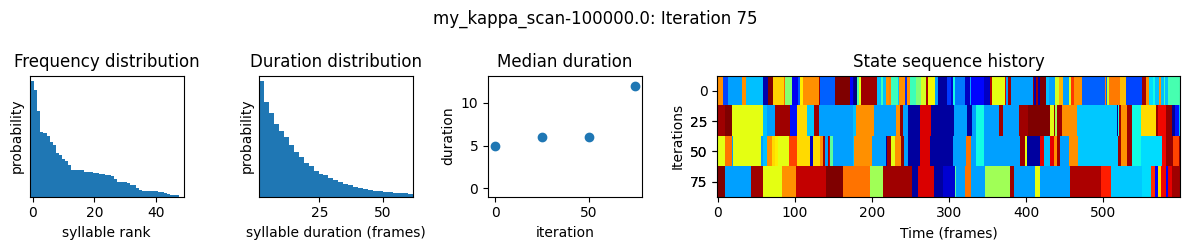

 98%|███████████████████████████████▎| 50/51 [2:50:04<03:25, 205.70s/it]

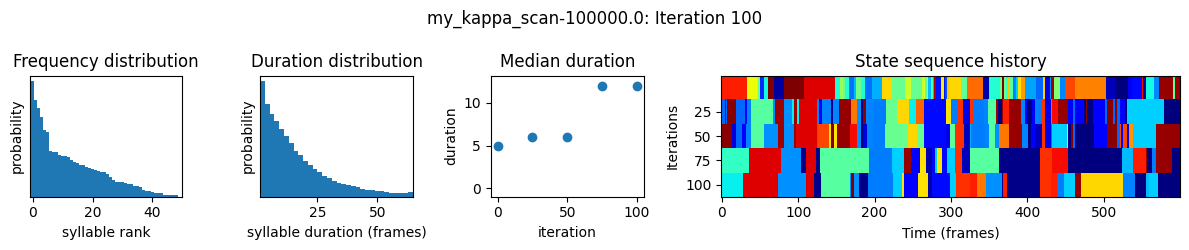

100%|████████████████████████████████| 51/51 [2:53:33<00:00, 204.18s/it]


Fitting model with kappa=1000000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000000.0


 49%|█████████████████▏                 | 25/51 [07:06<07:25, 17.14s/it]

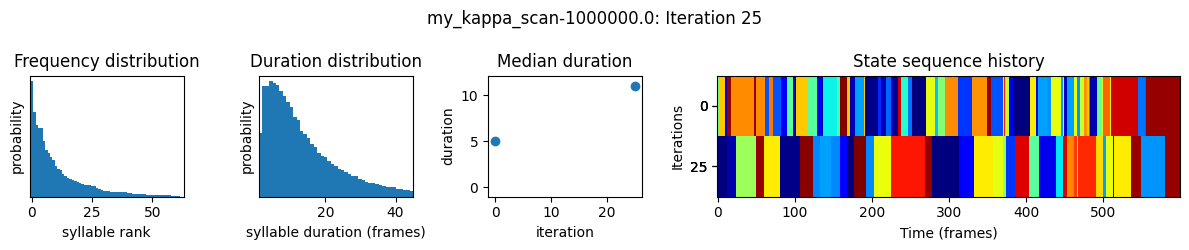

 98%|██████████████████████████████████▎| 50/51 [14:12<00:16, 16.96s/it]

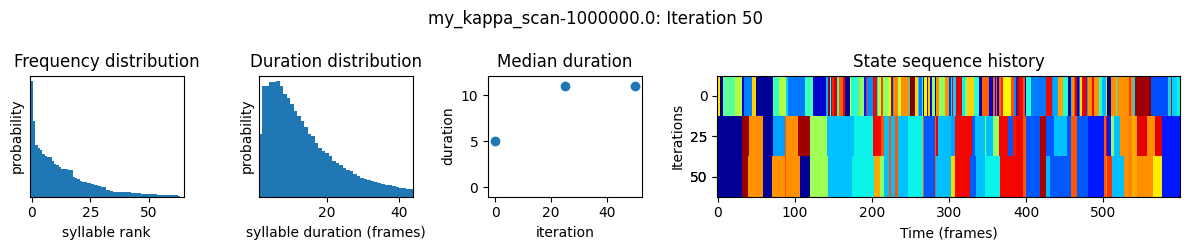

100%|███████████████████████████████████| 51/51 [14:31<00:00, 17.09s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000000.0


 49%|██████████████▋               | 25/51 [1:25:04<1:27:49, 202.66s/it]

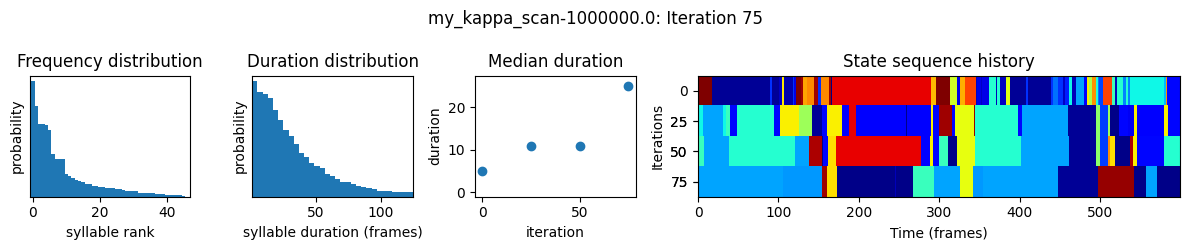

 98%|███████████████████████████████▎| 50/51 [2:50:38<03:23, 203.09s/it]

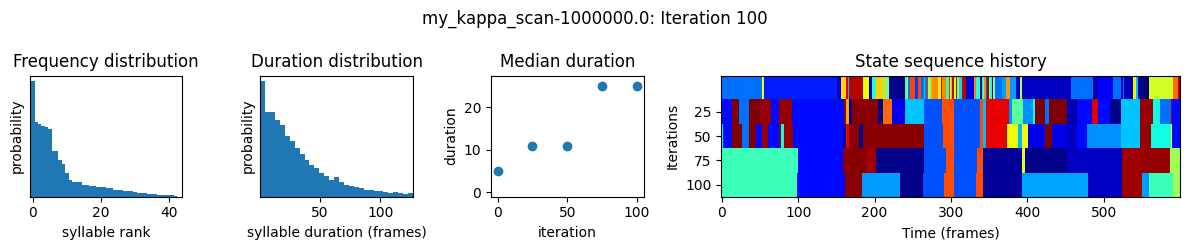

100%|████████████████████████████████| 51/51 [2:54:03<00:00, 204.77s/it]


Fitting model with kappa=10000000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000000.0


 49%|█████████████████▏                 | 25/51 [06:41<06:52, 15.85s/it]

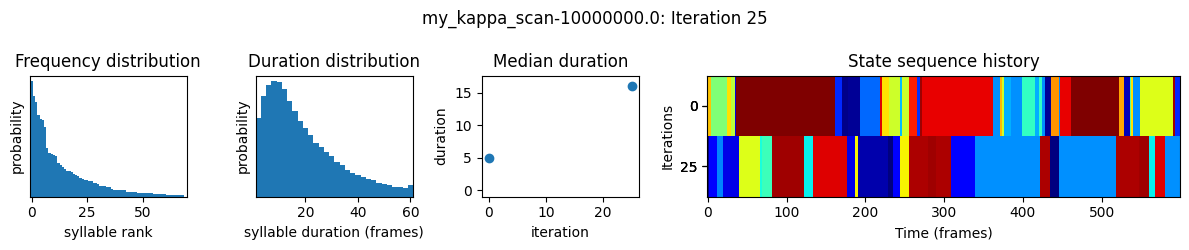

 98%|██████████████████████████████████▎| 50/51 [13:20<00:15, 15.92s/it]

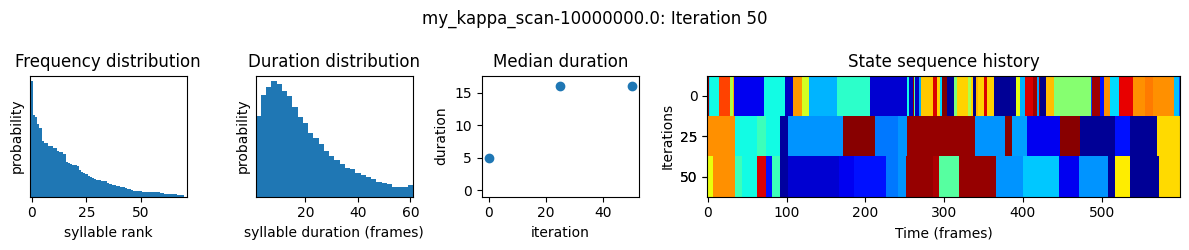

100%|███████████████████████████████████| 51/51 [13:37<00:00, 16.04s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000000.0


 49%|██████████████▋               | 25/51 [1:24:40<1:28:02, 203.19s/it]

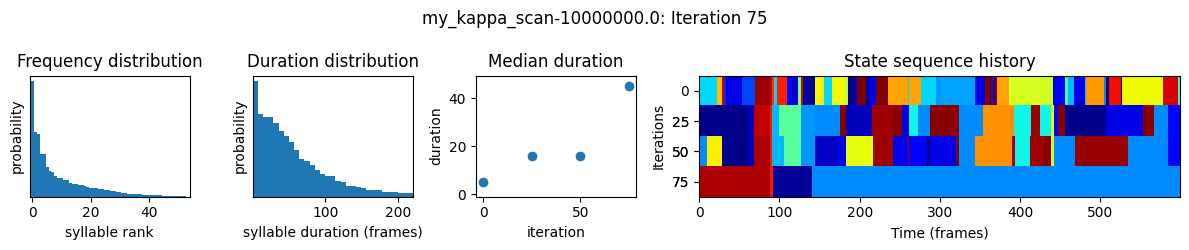

 98%|███████████████████████████████▎| 50/51 [2:50:18<03:24, 204.43s/it]

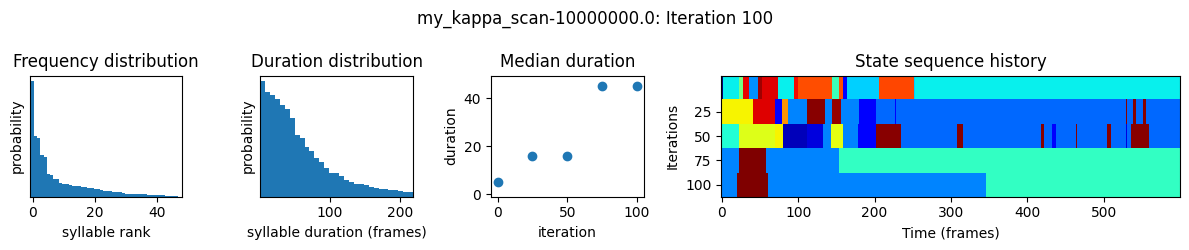

100%|████████████████████████████████| 51/51 [2:53:46<00:00, 204.44s/it]


Fitting model with kappa=100000000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000000.0


 49%|█████████████████▏                 | 25/51 [07:05<06:56, 16.04s/it]

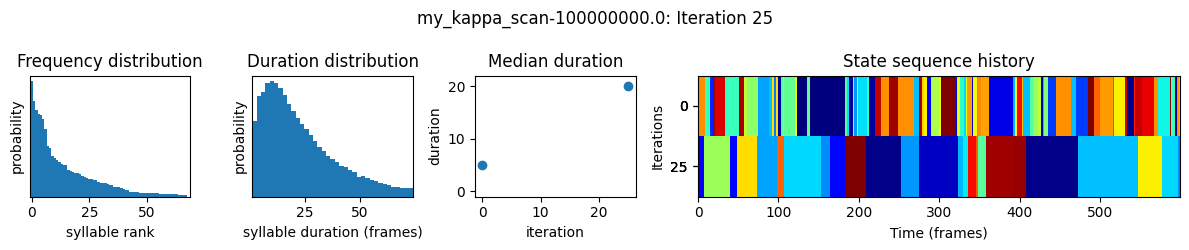

 98%|██████████████████████████████████▎| 50/51 [13:43<00:15, 15.85s/it]

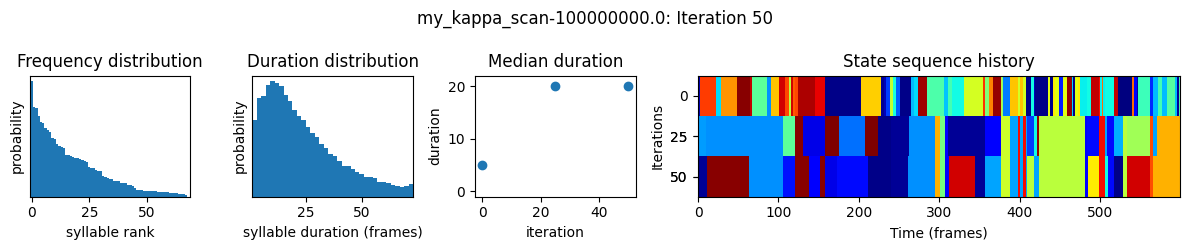

100%|███████████████████████████████████| 51/51 [14:00<00:00, 16.48s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000000.0


 49%|██████████████▋               | 25/51 [1:23:16<1:17:35, 179.04s/it]

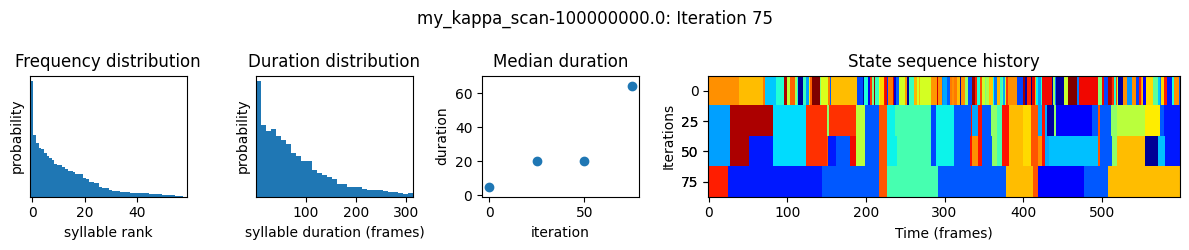

 98%|███████████████████████████████▎| 50/51 [2:29:38<02:36, 156.39s/it]

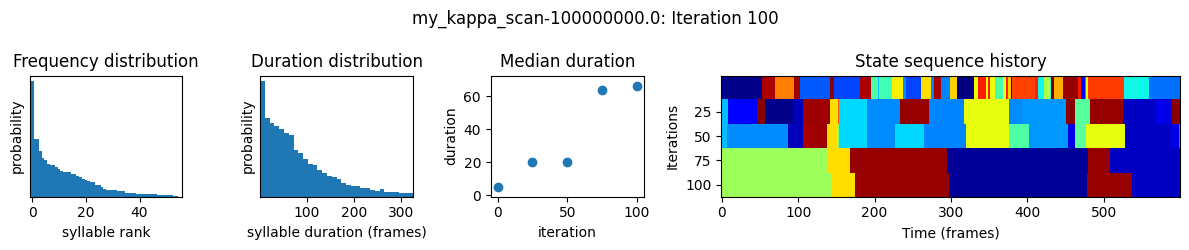

Loading checkpoints: 100%|██████████| 6/6 [00:01<00:00,  5.64it/s]


(<Figure size 800x250 with 2 Axes>, array([ 4.,  7., 12., 25., 45., 66.]))

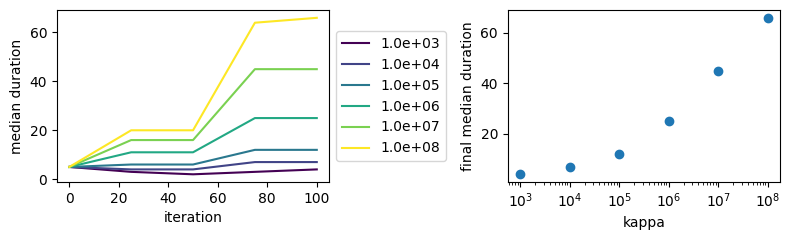

In [ ]:
'''
kappas = np.logspace(3,8,6)
decrease_kappa_factor = 10
num_ar_iters = 50
num_full_iters = 100

prefix = 'my_kappa_scan'

for kappa in kappas:
    print(f"Fitting model with kappa={kappa}")
    model_name = f'{prefix}-{kappa}'
    model = kpms.init_model(data, pca=pca, **config())

    # stage 1: fit the model with AR only
    model = kpms.update_hypparams(model, kappa=kappa)
    model = kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=True,
        num_iters=num_ar_iters,
        save_every_n_iters=25
    )[0];

    # stage 2: fit the full model
    model = kpms.update_hypparams(model, kappa=kappa/decrease_kappa_factor)
    kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=False,
        start_iter=num_ar_iters,
        num_iters=num_full_iters,
        save_every_n_iters=25
    );

kpms.plot_kappa_scan(kappas, kpmoseq_dir, prefix)

'''

### Loading a trained model and continue training from last checkpoint (iteration)

In [ ]:
'''
kappa = 1.0e5
model_name = "my_kappa_scan-100000.0"

model_to_fit, data, metadata, current_iter = kpms.load_checkpoint(
    kpmoseq_dir, model_name
)

# modify kappa to maintain the desired syllable time-scale
model_to_fit = kpms.update_hypparams(model_to_fit, kappa = kappa)


# run fitting for an additional 300 iters
model = kpms.fit_model(
    model_to_fit,
    data,
    metadata,
    kpmoseq_dir,
    f"fullModel_{kappa}",
    ar_only=False,
    start_iter=current_iter,
    num_iters=current_iter + 300,
)[0]

'''

### Training a new model with a pre selected kappa value 

Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS_multiAnimal\fu
llModel_1000000.0


 49%|█████████████████▏                 | 25/51 [09:30<09:51, 22.75s/it]

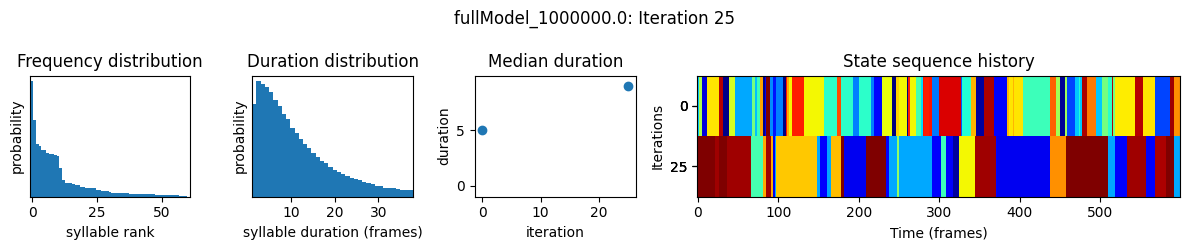

 98%|██████████████████████████████████▎| 50/51 [18:59<00:22, 22.54s/it]

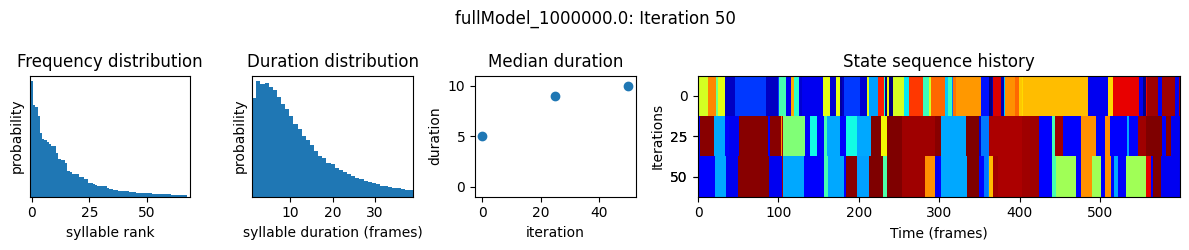

100%|███████████████████████████████████| 51/51 [19:24<00:00, 22.83s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS_multiAnimal\fu
llModel_1000000.0


  8%|██▎                         | 25/301 [2:01:21<22:03:50, 287.79s/it]

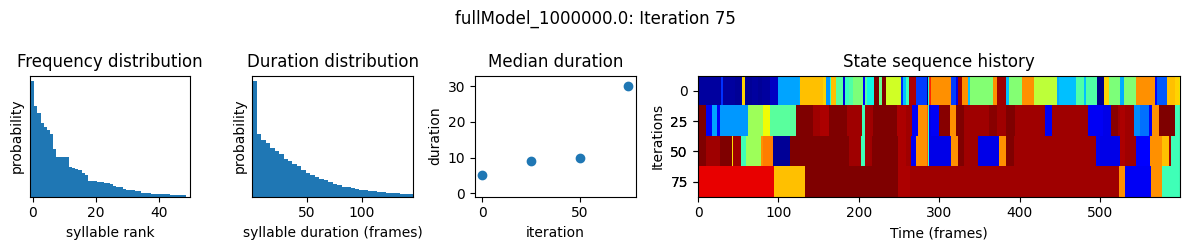

 17%|████▋                       | 50/301 [3:58:09<20:14:48, 290.39s/it]

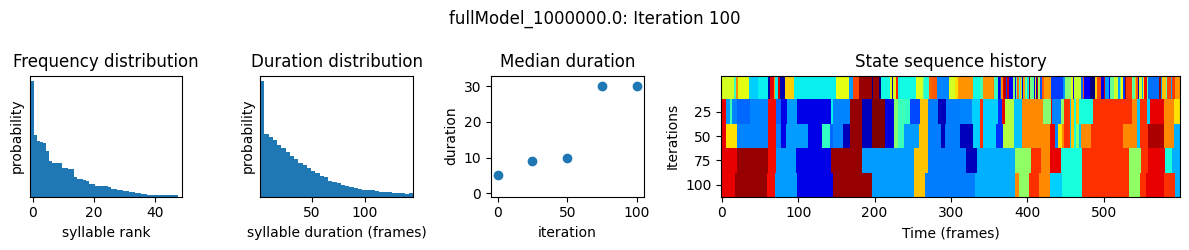

 25%|██████▉                     | 75/301 [5:55:25<16:22:45, 260.91s/it]

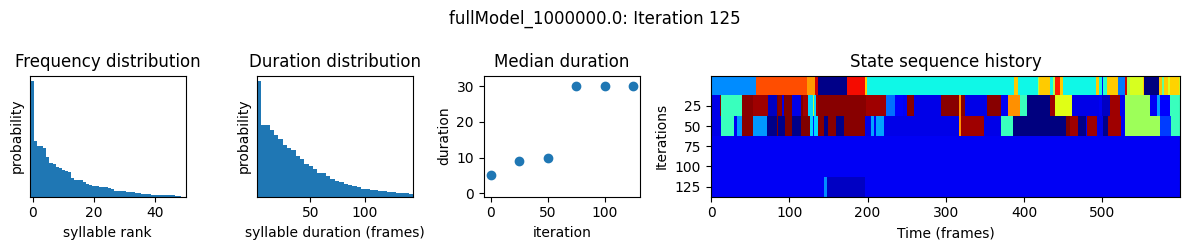

 33%|████████▉                  | 100/301 [7:48:58<14:20:11, 256.77s/it]

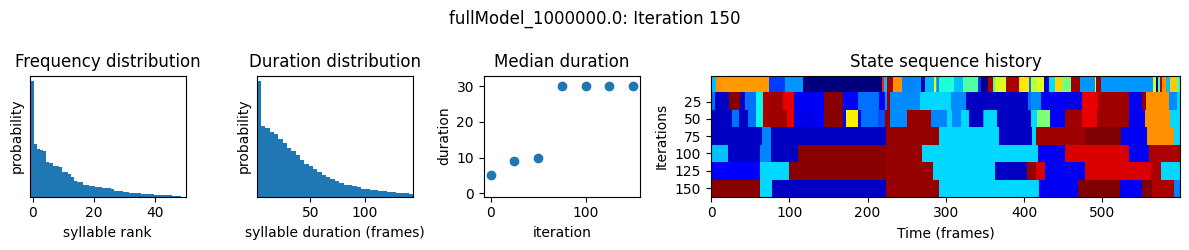

 42%|███████████▏               | 125/301 [9:46:12<14:51:24, 303.89s/it]

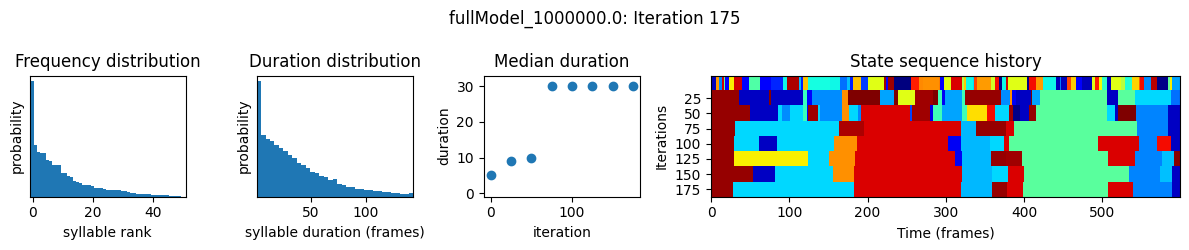

 50%|████████████▉             | 150/301 [11:39:05<10:41:36, 254.95s/it]

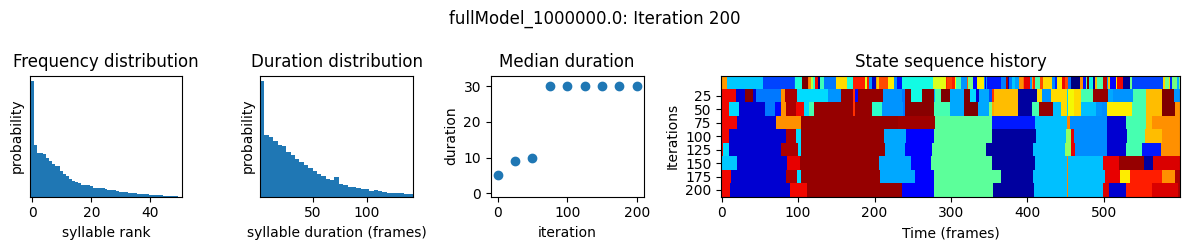

 58%|███████████████           | 175/301 [13:34:03<10:10:26, 290.69s/it]

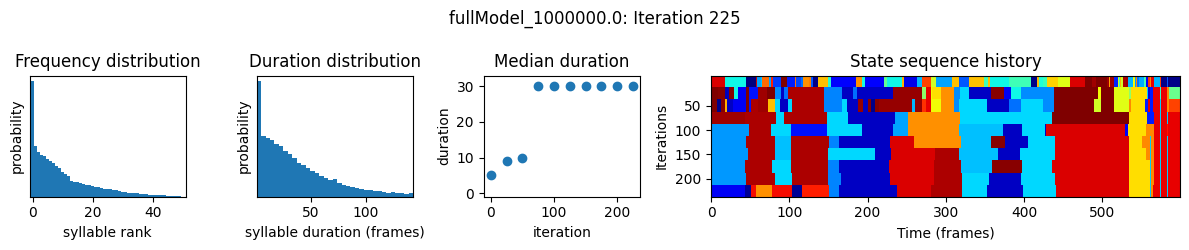

 60%|████████████████▏          | 180/301 [13:57:32<9:03:46, 269.64s/it]

: 

In [ ]:
'''
num_ar_iters = 50
kappa = 1e6
model_name = f"fullModel_{kappa}"

model = kpms.init_model(data, pca=pca, **config())
model = kpms.update_hypparams(model, kappa=kappa)

model, model_name = kpms.fit_model(model, 
                                   data, 
                                   metadata, 
                                   model_name = model_name, 
                                   project_dir = kpmoseq_dir, 
                                   ar_only=True, 
                                   num_iters=num_ar_iters
)

model, data, metadata, current_iter = kpms.load_checkpoint(kpmoseq_dir, 
                                                           model_name, 
                                                           iteration=num_ar_iters
)

model = kpms.fit_model(model,
                       data,
                       metadata,
                       kpmoseq_dir,
                       model_name,
                       ar_only=False,
                       start_iter=current_iter,
                       num_iters=current_iter + 300)[0]
'''

## Generating results

In [39]:
kappa = 1e6
model_name = f"fullModel_{kappa}"

# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(kpmoseq_dir, model_name);

model, data, metadata, current_iter = kpms.load_checkpoint(kpmoseq_dir,
                                                           model_name)


Reindexing: 100%|███████████| 13/13 [00:12<00:00,  1.03model snapshot/s]


In [42]:
# extract results
results = kpms.extract_results(model, 
                               metadata, 
                               kpmoseq_dir, 
                               model_name,)

Saved results to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR
\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\re
sults.h5


In [ ]:
results = kpms.load_results(kpmoseq_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())

'\nresults = kpms.load_results(kpmoseq_dir, model_name)\nkpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())\n'

In [ ]:

kpms.generate_grid_movies(results, kpmoseq_dir, model_name, coordinates=coordinates, **config(), overlay_keypoints=True);


Writing grid movies to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS_multiAnimal\fullModel_1000000.0\grid_movies
Using window size of 304 pixels


Generating grid movies: 100%|███████████| 33/33 [07:06<00:00, 12.93s/it]


In [ ]:

kpms.plot_similarity_dendrogram(coordinates, results, kpmoseq_dir, model_name, **config())

'\nkpms.plot_similarity_dendrogram(coordinates, results, kpmoseq_dir, model_name, **config())\n'

## Applying to entire dataset

In [47]:
dataset = []

for f in dlc_folders_dataset:
    folder = Path(f).parent.parent 
    if (folder/"flag1.txt").exists() or not (folder/"flag.txt").exists():
        dataset.append(str(next(folder.rglob(rf"*{pcutoff}_skeleton\*snapshot_best-100_sk.h5"))))
    elif (folder/"flag.txt").exists() and not (folder/"flag1.txt").exists():
        dataset.append(str(next(folder.rglob(rf"*{pcutoff}_transformer\*snapshot_best-100_sk_tr.h5"))))


In [48]:
import re

def extract_id(k):
    m = re.search(r"(mouse\d+).*?Day(\d+)", k)
    if not m:
        return None
    return f"{m.group(1)}_Day{m.group(2)}"

def clean_keys(d):
    new_d = {}
    for k, v in d.items():
        new_key = extract_id(k)
        if new_key is None:
            continue  # or raise error if you prefer
        new_d[new_key] = v
    return new_d

Models:  [Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_KPMS/fullModel_100000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_KPMS/fullModel_1000000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_KPMS/fullModel_10000000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_KPMS/fullModel_100000000.0')]


100%|█████████████████████████████████████| 4/4 [02:45<00:00, 41.34s/it]


Best model: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_100000.0


(<Figure size 400x350 with 1 Axes>, <Axes: ylabel='EML score'>)

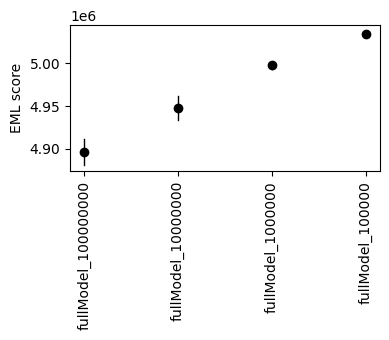

In [49]:
model_names = [f for f in Path(kpmoseq_dir).rglob("fullModel*")]
print("Models: ", model_names)

eml_scores, eml_std_errs = kpms.expected_marginal_likelihoods(kpmoseq_dir, model_names)
best_model = model_names[np.argmax(eml_scores)]
print(f"\nBest model: {best_model}")

kpms.plot_eml_scores(eml_scores, eml_std_errs, [str(Path(f).stem) for f in model_names])

In [50]:
# The model with kappa = 1e5 generates syllables with a median duration of around 23 frames = 460ms

model = kpms.load_checkpoint(kpmoseq_dir, best_model)[0]

# load new data (e.g. from deeplabcut)
new_data = dataset
coordinates, confidences, bodyparts = kpms.load_keypoints(new_data, 
                                                          "deeplabcut", 
                                                          path_in_name=True, 
                                                          exclude_individuals=exclude)

coordinates = clean_keys(coordinates)
confidences = clean_keys(confidences)

coordinates, confidences = kpms.outlier_removal(coordinates,
                                                confidences,
                                                kpmoseq_dir,
                                                overwrite=False,
                                                **config())

data, metadata = kpms.format_data(coordinates, 
                                  confidences, 
                                  **config())

Loading keypoints:   2%|▎               | 4/249 [00:00<00:15, 15.49it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:   3%|▌               | 8/249 [00:00<00:14, 16.73it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:   5%|▋              | 12/249 [00:00<00:13, 17.75it/s]

...

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:  98%|█████████████▋| 243/249 [00:14<00:00, 17.37it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints: 100%|██████████████| 249/249 [00:14<00:00, 17.21it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


In [51]:
# apply saved model to new data
results = kpms.apply_model(model, 
                           data, 
                           metadata, 
                           kpmoseq_dir, 
                           model_name,
                           num_iter = 150,
                           overwrite=True, 
                           **config())

Applying model: 100%|███████████| 500/500 [214:16:48<00:00, 1542.82s/it]


Saved results to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR
\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\re
sults.h5


In [ ]:
results = kpms.load_results(kpmoseq_dir, model_name)

filtered_results = {
    k: v for k, v in results.items()
    if "_topView_compDLC_" not in k # These were keys that come from a previous iteration of the model training. They have duplicates in the correct format 
}
genResPlots = False
if len(coordinates.keys()) == len(filtered_results.keys()):
    genResPlots = True

Saving trajectory plots to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\trajectory_plots


Generating trajectory plots: 100%|██████| 31/31 [00:24<00:00,  1.25it/s]


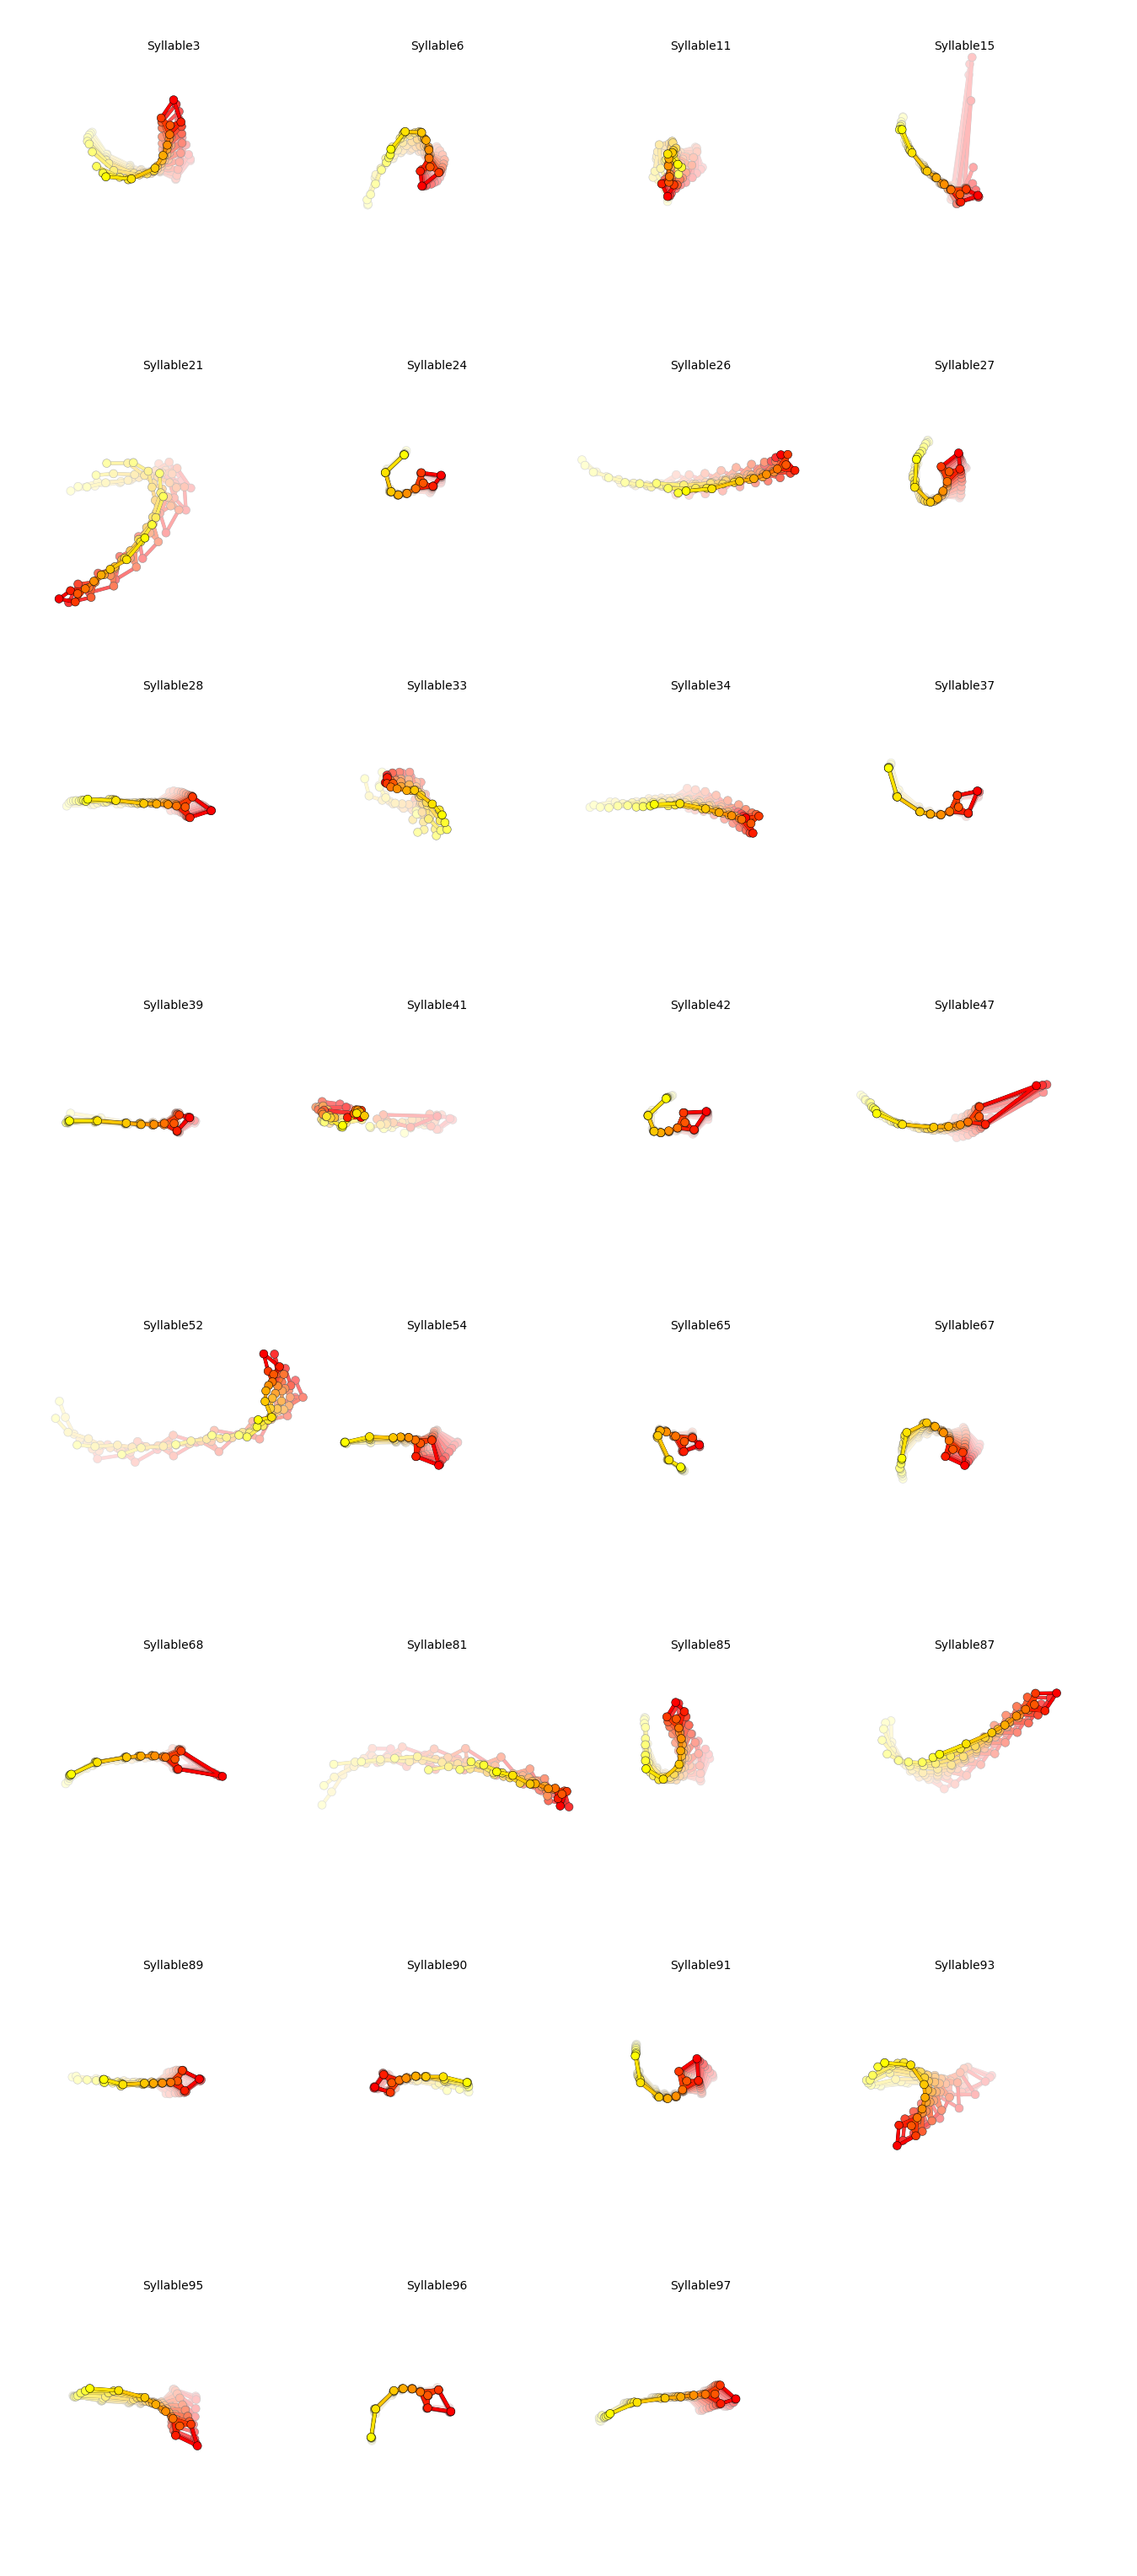

In [77]:
if genResPlots:
    kpms.generate_trajectory_plots(coordinates, filtered_results, kpmoseq_dir, model_name, **config())

In [ ]:
key_path = {}
for k in coordinates.keys():
    for p in new_data:
        if k in p:
            P = next(Path(p).parent.parent.glob("*topView*.avi"))
            key_path[k] = str(P)

In [95]:
if genResPlots:
    kpms.generate_grid_movies(filtered_results, kpmoseq_dir, model_name, video_paths = key_path, coordinates=coordinates, **config(), overlay_keypoints=True)

Writing grid movies to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\grid_movies
Using window size of 304 pixels


Generating grid movies: 100%|███████████| 31/31 [07:56<00:00, 15.37s/it]


Saving dendrogram plot to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\similarity_dendrogram


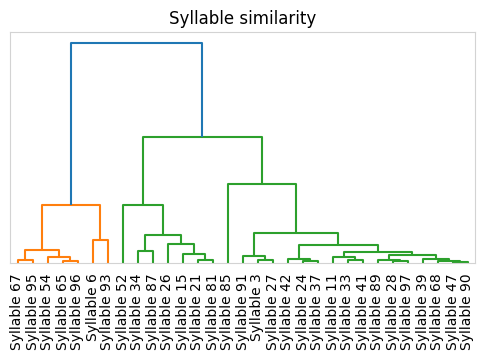

In [96]:
if genResPlots:    
    kpms.plot_similarity_dendrogram(coordinates, filtered_results, kpmoseq_dir, model_name, **config())

In [ ]:
# Groups

Agg = ["975826", "975827", "975833", "978772", "978774", "988590", "997838", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978775", "1010819", "997839", "997840", "997841", "1029736", "1029739", "1032216"]
maladaptive = ["978513", "978527", "978528", "1010832", "1013590", "1034805", "1034814"]

In [ ]:
filtered_results["mouse978"]

In [313]:
import pandas as pd

#del filtered_results["mouse1013590_Day19"]

rows = []
skipped = []

saline_mice = maladaptive[:3]
psilo_mice = maladaptive[3:]   # non-overlapping

for rec in filtered_results.keys():

    m = re.match(r"mouse(\d+)_Day(\d+)", rec)

    if m is None:
        skipped.append({"recording": rec, "reason": "regex_no_match"})
        continue

    mouse = m.group(1)
    day = int(m.group(2))

    if mouse in Agg:
        group = "Agg"

    elif mouse in nonAgg:
        group = "nonAgg"

    elif mouse in maladaptive and day <= 5:
        group = "maladaptive baseline"

    elif mouse in psilo_mice and day >= 15:
        group = "maladaptive after Psilocybin"

    elif mouse in saline_mice and day >= 15:
        group = "maladaptive after Saline"

    else:
        skipped.append({
            "recording": rec,
            "mouse": mouse,
            "day": day,
            "reason": "mouse_not_in_group_lists"
        })
        continue

        
    # treat same physical mouse in different phase/group as separate unit
    mouse_group_id = f"{mouse}_{group}"

    rows.append({
        "recording": rec,
        "mouse": mouse,                 # original animal ID
        "mouse_group_id": mouse_group_id, # analysis ID
        "day": day,
        "group": group
    })

meta = pd.DataFrame(rows)
skipped_df = pd.DataFrame(skipped)

In [307]:
skipped_df

,recording,mouse,day,reason
0,mouse1010832_Day17,1010832,17,mouse_not_in_group_lists
1,mouse1010832_Day18,1010832,18,mouse_not_in_group_lists
2,mouse1010832_Day19,1010832,19,mouse_not_in_group_lists
3,mouse1013590_Day17,1013590,17,mouse_not_in_group_lists
4,mouse1013590_Day18,1013590,18,mouse_not_in_group_lists
5,mouse1034805_Day19,1034805,19,mouse_not_in_group_lists
6,mouse1034814_Day17,1034814,17,mouse_not_in_group_lists
7,mouse1034814_Day18,1034814,18,mouse_not_in_group_lists
8,mouse1034814_Day19,1034814,19,mouse_not_in_group_lists
9,mouse978513_Day16,978513,16,mouse_not_in_group_lists


In [314]:
import numpy as np

all_syllables=[]

for rec in filtered_results:
    all_syllables.extend(
        filtered_results[rec]["syllable"]
    )

n_syll = len(np.unique(all_syllables))

In [315]:
usage = []

for rec in filtered_results:

    s = np.asarray(filtered_results[rec]["syllable"])

    row = {"recording": rec}

    if len(s) == 0:
        freq = np.zeros(n_syll)
    else:
        counts = np.bincount(s, minlength=n_syll)
        total = counts.sum()

        if total == 0:
            freq = np.zeros(n_syll)
        else:
            freq = counts / total

    for i, f in enumerate(freq):
        row[f"syll_{i}"] = f

    usage.append(row)

usage = pd.DataFrame(usage).fillna(0)

df = meta.merge(usage, on="recording", how="inner")

In [316]:
mouse_df = (
    df.groupby(["mouse_group_id", "group"])
    .mean(numeric_only=True)
    .reset_index()
)

syll_77    1.285797
syll_46    1.057730
syll_43    1.040285
syll_17    1.009602
syll_52    0.859807
syll_21    0.857673
syll_48    0.814650
syll_81    0.748012
syll_29    0.638354
syll_31    0.550096
syll_70    0.534676
syll_75    0.478640
syll_11    0.448838
syll_85    0.426958
syll_26    0.376981
syll_95    0.364966
syll_88    0.355126
syll_28    0.349340
syll_20    0.347540
dtype: float64


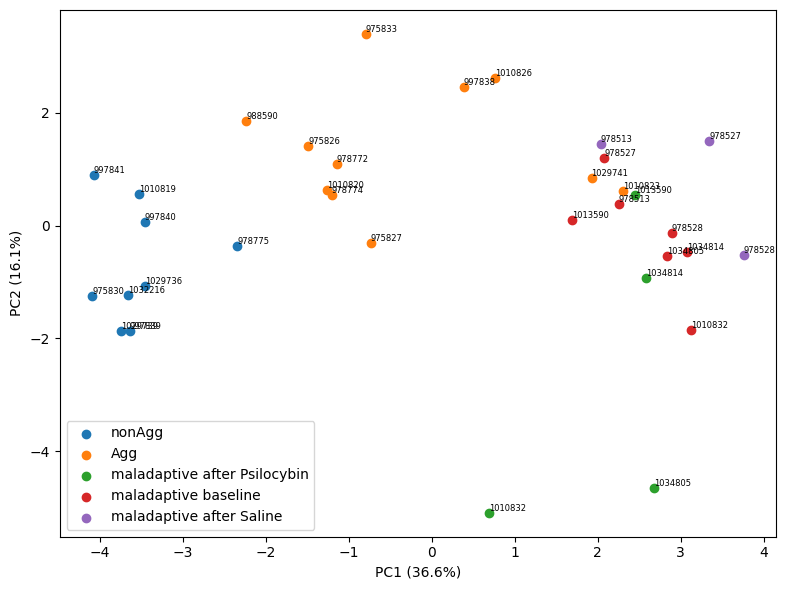

In [317]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# -----------------------------
# average sessions per analysis mouse
# -----------------------------
mouse_df = (
    df.groupby(["mouse_group_id", "mouse", "group"])
    .mean(numeric_only=True)
    .reset_index()
)

# -----------------------------
# features
# -----------------------------
X_df = mouse_df.filter(regex="^syll_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# log transform
X_log = np.log(X_df + 1e-8)

# target for mutual information
y = LabelEncoder().fit_transform(mouse_df["group"])

# scale before MI/PCA
X_scaled = StandardScaler().fit_transform(X_log)

# mutual information feature scores
mi = mutual_info_classif(X_scaled, y, random_state=42)

mi_scores = pd.Series(mi, index=X_df.columns).sort_values(ascending=False)

# choose top N syllables
top_n = max(2, int(n_syll / 3))
top_features = mi_scores.head(top_n).index

print(mi_scores.head(top_n))

# -----------------------------
# PCA using MI-selected features
# -----------------------------
X_selected = X_log[top_features]
X_selected = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected)

# -----------------------------
# plot
# -----------------------------
plt.figure(figsize=(8, 6))

for g in mouse_df.group.unique():
    idx = mouse_df.group == g
    plt.scatter(Y[idx, 0], Y[idx, 1], label=g)

for i, row in mouse_df.reset_index(drop=True).iterrows():
    plt.text(
        Y[i, 0],
        Y[i, 1],
        str(row["mouse_group_id"].split("_")[0]),
        fontsize=6,
        ha="left",
        va="bottom"
    )

plt.legend(loc="lower left")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.tight_layout()
plt.show()

In [346]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive": "#E65A5A"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive": "^"
}

group_order = ["nonAgg", "Agg", "maladaptive"]

# blue = negative, orange = middle, red = positive
pc_cmap = LinearSegmentedColormap.from_list(
    "blue_orange_red",
    ["#5AA2E6", "#E6A55A", "#E65A5A"]
)

# -----------------------------
# exclude psilocybin, merge other maladaptive groups
# -----------------------------
plot_df = mouse_df.copy()

plot_df = plot_df[
    plot_df["group"] != "maladaptive after Psilocybin"
].copy()

plot_df["group_merged"] = plot_df["group"].replace({
    "maladaptive baseline": "maladaptive",
    "maladaptive after Saline": "maladaptive"
})

# -----------------------------
# features
# -----------------------------
X_df = plot_df.filter(regex="^syll_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

min_recordings = 1
presence = (X_df > 0).sum(axis=0)
valid_features = presence[presence >= min_recordings].index
X_df = X_df[valid_features]

X_log = np.log(X_df + 1e-8)

# -----------------------------
# mutual information
# -----------------------------
y = LabelEncoder().fit_transform(plot_df["group_merged"])

X_scaled = StandardScaler().fit_transform(X_log)

mi = mutual_info_classif(X_scaled, y, random_state=42)

mi_scores = pd.Series(mi, index=X_df.columns).sort_values(ascending=False)

top_n = int(len(valid_features) / 3)
top_features = mi_scores.head(top_n).index

print(mi_scores.head(top_n))

# -----------------------------
# PCA
# -----------------------------
X_selected = X_log[top_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected_scaled)

plot_df["PC1"] = Y[:, 0]
plot_df["PC2"] = Y[:, 1]

# -----------------------------
# PC1 loadings
# -----------------------------
pc1_weights = pd.Series(
    pca.components_[0],
    index=top_features,
    name="PC1_weight"
)

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)

# -----------------------------
# PC1 distribution data
# -----------------------------
violin_data = [
    plot_df.loc[plot_df["group_merged"] == g, "PC1"].values
    for g in group_order
]

# -----------------------------
# per-group syllable contribution to PC1
# -----------------------------
X_selected_df = pd.DataFrame(
    X_selected_scaled,
    columns=top_features,
    index=plot_df.index
)

pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_merged"].values

group_pc1_contrib = (
    pc1_contrib
    .groupby("group")
    .mean()
    .T
)

top_heat_n = top_n

top_syllables = (
    group_pc1_contrib.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(top_heat_n)
    .index
)

heat = group_pc1_contrib.loc[top_syllables, group_order]

# same color range for loading barplot and heatmap
max_abs = max(
    np.abs(top_loadings.values).max(),
    np.abs(heat.values).max()
)

norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])

syll_52    0.975053
syll_21    0.860725
syll_81    0.748717
syll_31    0.631412
syll_85    0.519325
syll_11    0.478797
syll_6     0.366496
syll_97    0.366345
syll_26    0.359841
syll_7     0.342382
syll_33    0.333300
syll_20    0.327723
syll_42    0.322826
syll_95    0.317497
syll_48    0.314637
syll_80    0.298332
syll_28    0.278113
syll_72    0.275670
syll_88    0.275252
dtype: float64


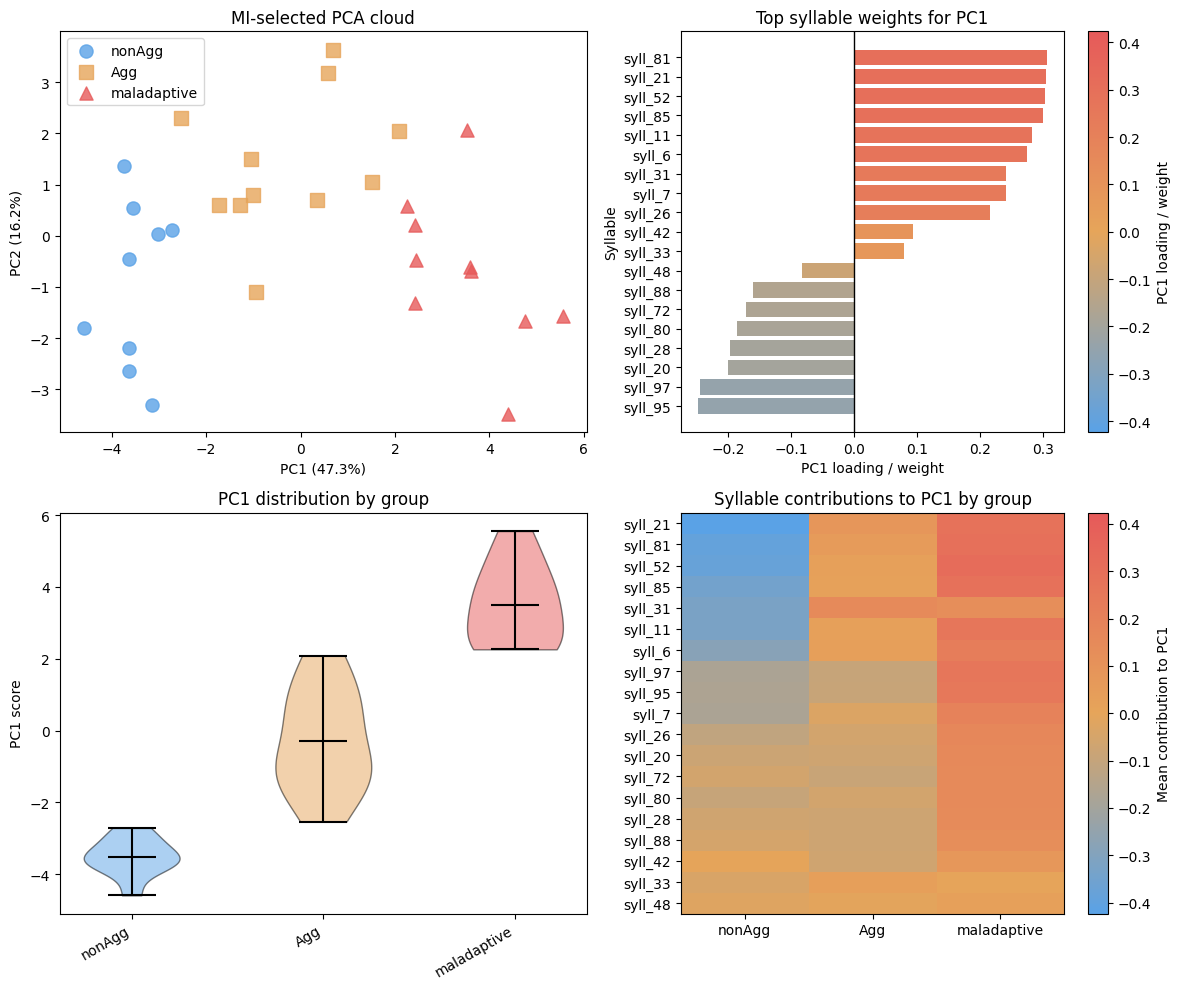

In [359]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# -----------------------------
# 1. PCA cloud
# -----------------------------
ax = axes[0, 0]

for g in group_order:
    idx = plot_df["group_merged"] == g

    ax.scatter(
        plot_df.loc[idx, "PC1"],
        plot_df.loc[idx, "PC2"],
        label=g,
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.8,
        s=90
    )

ax.legend(loc="upper left")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("MI-selected PCA cloud")

# -----------------------------
# 2. Top PC1 syllable weights
# -----------------------------
ax = axes[0, 1]

bar_colors = [pc_cmap(norm(v)) for v in top_loadings.values]

ax.barh(
    top_loadings.index,
    top_loadings.values,
    color=bar_colors
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("PC1 loading / weight")
ax.set_ylabel("Syllable")
ax.set_title("Top syllable weights for PC1")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PC1 loading / weight")

# -----------------------------
# 3. PC1 violin plot by group
# -----------------------------
ax = axes[1, 0]

vp = ax.violinplot(
    violin_data,
    showmeans=True,
    showmedians=False
)

for body, g in zip(vp["bodies"], group_order):
    body.set_facecolor(group_colors[g])
    body.set_edgecolor("black")
    body.set_alpha(0.5)

for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")

ax.set_xticks(np.arange(1, len(group_order) + 1))
ax.set_xticklabels(group_order, rotation=30, ha="right")
ax.set_ylabel("PC1 score")
ax.set_title("PC1 distribution by group")

# -----------------------------
# 4. Syllable contributions to PC1 by group
# -----------------------------
ax = axes[1, 1]

im = ax.imshow(
    heat,
    aspect="auto",
    cmap=pc_cmap,
    norm=norm
)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns)

ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)

ax.set_title("Syllable contributions to PC1 by group")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mean contribution to PC1")

plt.tight_layout()
plt.show()

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

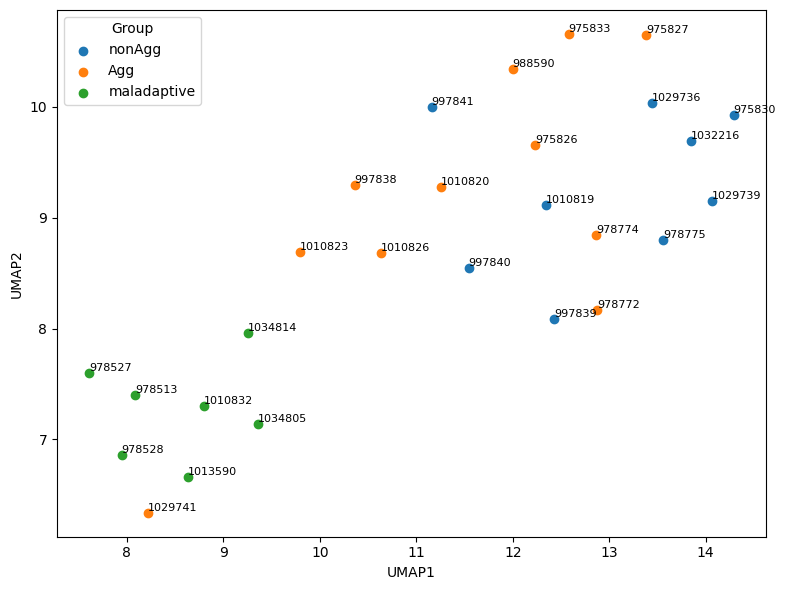

In [154]:
import umap

X = mouse_df.filter(regex="^syll_")
X = np.log(X + 1e-8)
X = StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    min_dist=0.3,
    metric="correlation",
    random_state=42
)

Y = reducer.fit_transform(X)

plt.figure(figsize=(8, 6))

for g in mouse_df.group.unique():
    idx = mouse_df.group == g
    plt.scatter(Y[idx, 0], Y[idx, 1], label=g)

# label each mouse
for i, row in mouse_df.reset_index(drop=True).iterrows():
    plt.text(
        Y[i, 0],
        Y[i, 1],
        str(row["mouse"]),
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.legend(title="Group")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()

syll_21    0.476017
syll_81    0.376700
syll_52    0.332402
syll_31    0.310117
syll_33    0.298574
syll_85    0.295906
syll_95    0.240885
syll_27    0.186953
syll_68    0.183522
syll_97    0.179592
syll_36    0.176951
syll_28    0.176092
syll_11    0.165394
syll_15    0.163839
syll_87    0.149139
syll_47    0.134966
syll_39    0.133470
syll_20    0.130662
syll_67    0.124231
syll_34    0.122394
syll_6     0.121322
syll_77    0.117606
syll_12    0.115597
syll_7     0.110886
syll_42    0.107656
dtype: float64


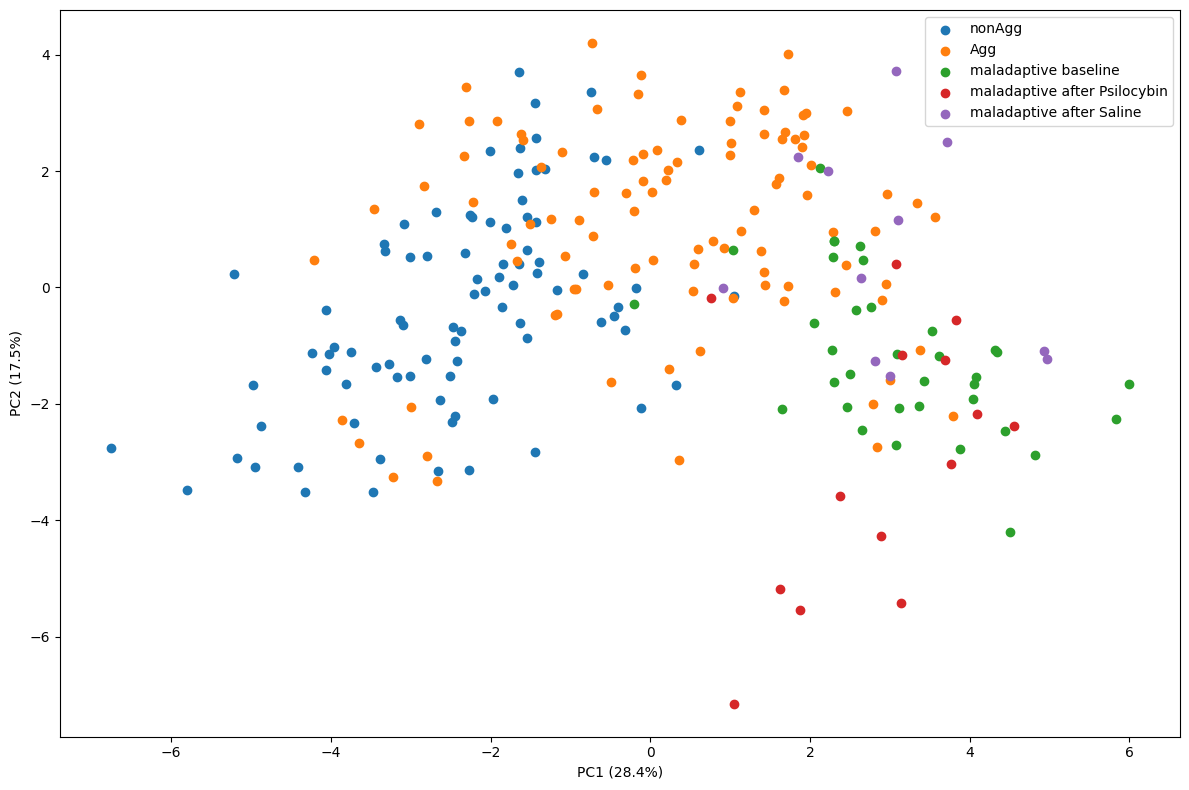

In [250]:
# one row = one mouse-day/session
session_df = df.copy()

# features
X_df = session_df.filter(regex="^syll_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# log transform
X_log = np.log(X_df + 1e-8)

# target for mutual information
y = LabelEncoder().fit_transform(session_df["group"])

# scale before MI/PCA
X_scaled = StandardScaler().fit_transform(X_log)

# mutual information scores
mi = mutual_info_classif(X_scaled, y, random_state=42)

mi_scores = pd.Series(mi, index=X_df.columns).sort_values(ascending=False)

# choose top N syllables
top_n = 25
top_features = mi_scores.head(top_n).index

print(mi_scores.head(top_n))

# PCA on MI-selected syllables
X_selected = X_log[top_features]
X_selected = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=5)
Y = pca.fit_transform(X_selected)

plt.figure(figsize=(12, 8))

for g in session_df.group.unique():
    idx = session_df.group == g
    plt.scatter(Y[idx, 0], Y[idx, 1], label=g)

plt.legend()
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.tight_layout()
plt.show()

syll_21    0.438484
syll_81    0.315745
syll_52    0.310795
syll_31    0.290397
syll_85    0.257144
syll_33    0.249795
syll_39    0.196295
syll_27    0.191022
syll_95    0.188202
syll_11    0.149594
syll_36    0.145529
syll_97    0.142233
syll_28    0.141599
syll_47    0.139456
syll_20    0.134234
syll_12    0.126196
syll_7     0.119298
syll_34    0.119259
syll_67    0.118519
dtype: float64


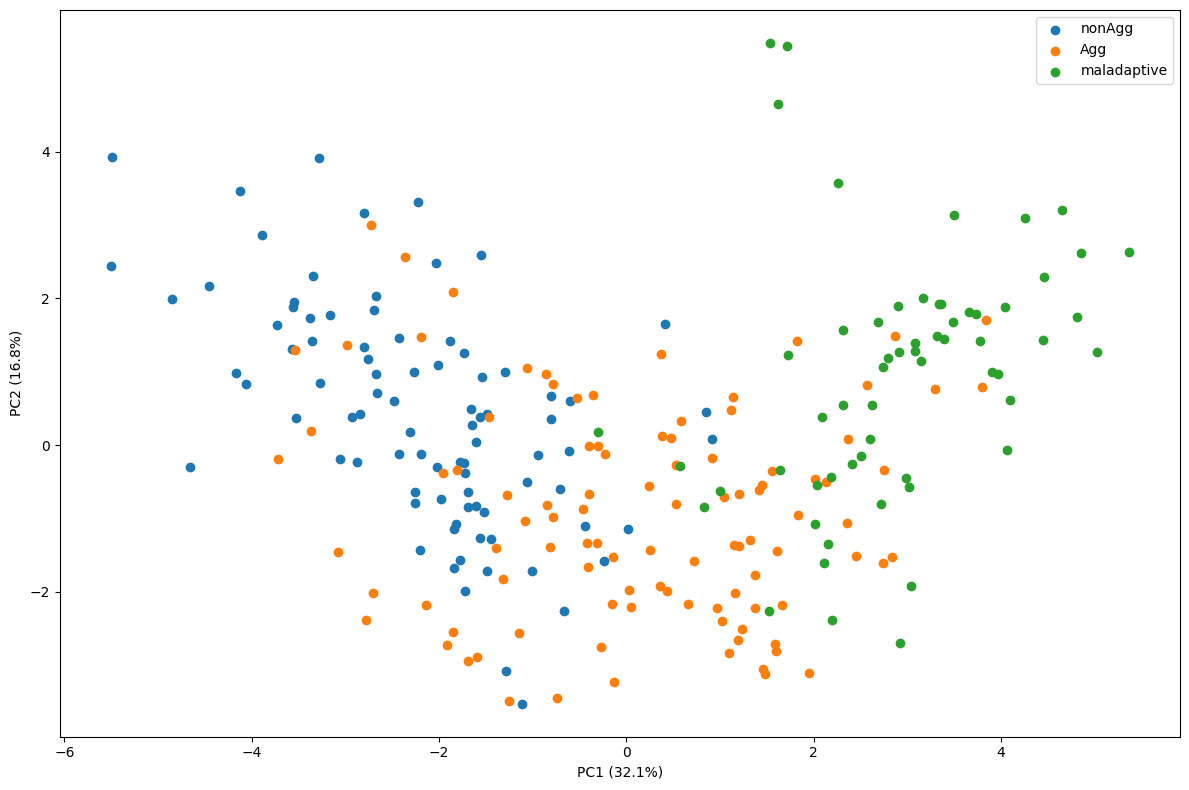

In [263]:
# one row = one mouse-day/session
session_df = df.copy()

# exclude psilocybin, merge other maladaptive groups
'''
session_df = session_df[
    session_df["group"] != "maladaptive after Psilocybin"
].copy()
'''

session_df["group_merged"] = session_df["group"].replace({
    "maladaptive baseline": "maladaptive",
    "maladaptive after Saline": "maladaptive",
    "maladaptive after Psilocybin": "maladaptive"
})

# features
X_df = session_df.filter(regex="^syll_").copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# log transform
X_log = np.log(X_df + 1e-8)

# target for mutual information
y = LabelEncoder().fit_transform(session_df["group_merged"])

# scale before MI/PCA
X_scaled = StandardScaler().fit_transform(X_log)

# mutual information scores
mi = mutual_info_classif(X_scaled, y, random_state=42)

mi_scores = pd.Series(mi, index=X_df.columns).sort_values(ascending=False)

# choose top N syllables
top_n = 19
top_features = mi_scores.head(top_n).index

print(mi_scores.head(top_n))

# PCA on MI-selected syllables
X_selected = X_log[top_features]
X_selected = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=5)
Y = pca.fit_transform(X_selected)

plt.figure(figsize=(12, 8))

for g in session_df.group_merged.unique():
    idx = session_df.group_merged == g
    plt.scatter(Y[idx, 0], Y[idx, 1], label=g)

plt.legend()
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.tight_layout()
plt.show()

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

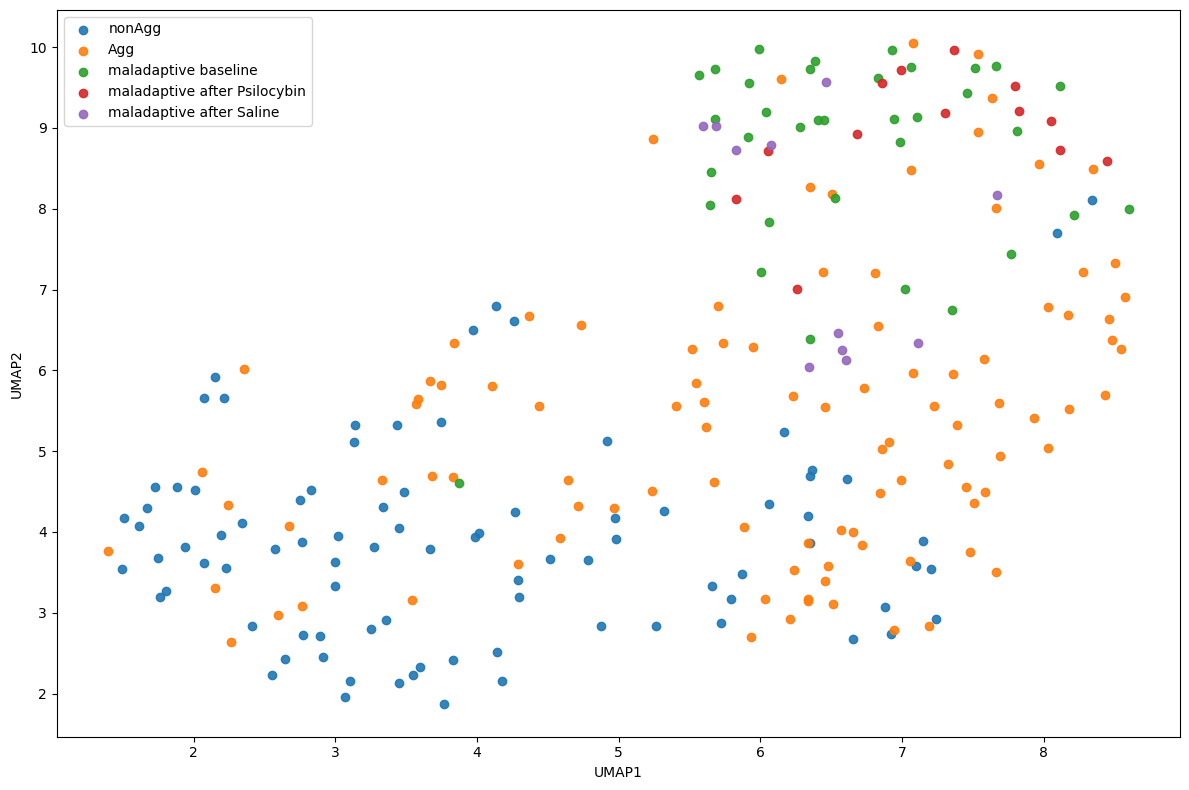

In [339]:
# pip install umap-learn   # run once if needed

import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# one row = one mouse-day/session
session_df = df.copy()

X = session_df.filter(regex="^syll_")
X = np.log(X + 1e-8)
X = StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=10,     # try 5–20
    min_dist=0.3,       # try 0.1–0.5
    metric="correlation",
    random_state=42
)

Y = reducer.fit_transform(X)

plt.figure(figsize=(12,8))

for g in session_df.group.unique():

    idx = session_df.group == g

    plt.scatter(
        Y[idx,0],
        Y[idx,1],
        label=g,
        alpha=0.9
    )

'''
# optional labels
for i,row in session_df.reset_index(drop=True).iterrows():

    plt.text(
        Y[i,0],
        Y[i,1],
        f"{row['mouse']}_D{int(row['day']):02d}",
        fontsize=6
    )
'''

plt.legend()
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()

syll_21    0.438484
syll_81    0.315745
syll_52    0.308107
syll_31    0.305750
syll_85    0.257144
syll_33    0.243075
syll_39    0.234796
syll_27    0.191022
syll_95    0.188202
syll_11    0.149594
syll_97    0.142233
syll_28    0.141599
syll_47    0.139456
syll_20    0.137210
syll_36    0.135870
dtype: float64


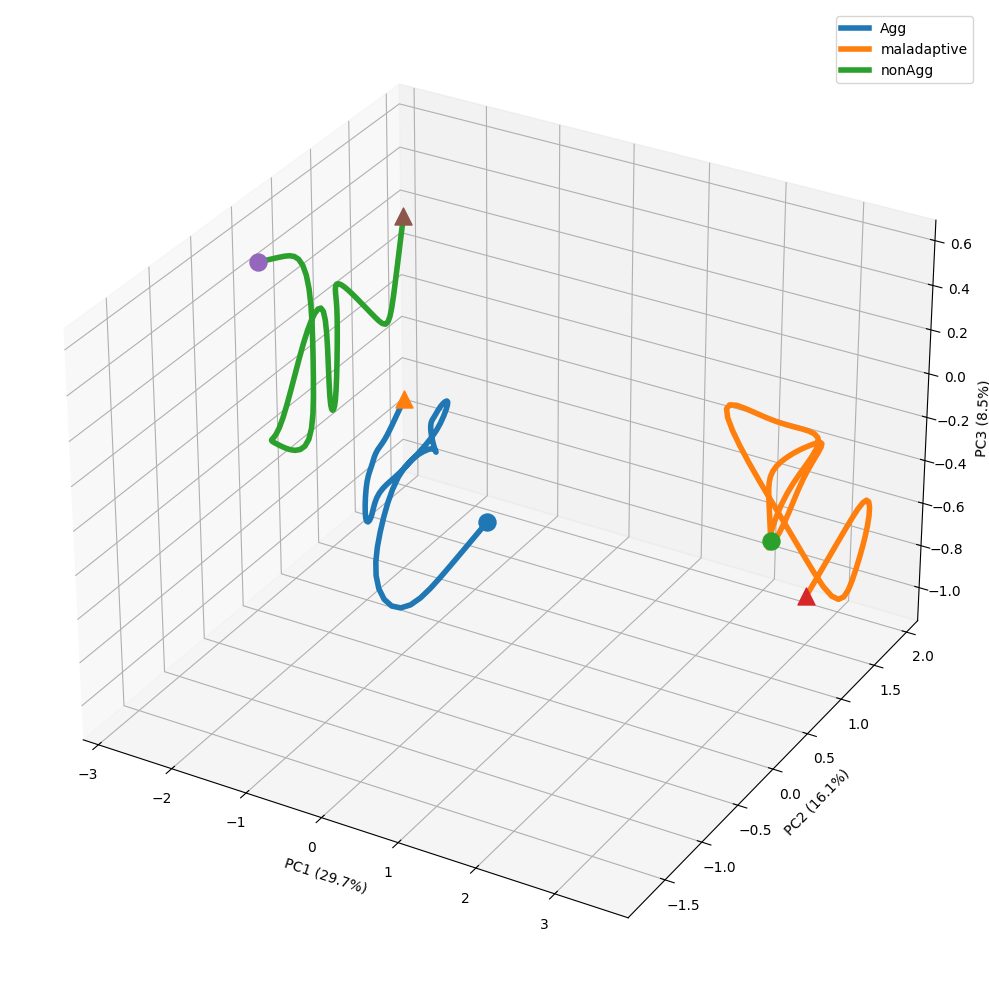

In [188]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

import matplotlib.pyplot as plt

# -----------------------------------
# session data
# one row = one mouse-session
# -----------------------------------

session_df = df.copy()
session_df = session_df.sort_values(["mouse","day"])

# -----------------------------------
# MI feature selection
# -----------------------------------

X_df = session_df.filter(regex="^syll_")

X_log = np.log(X_df + 1e-8)

y = LabelEncoder().fit_transform(
    session_df["group"]
)

X_scaled = StandardScaler().fit_transform(
    X_log
)

mi = mutual_info_classif(
    X_scaled,
    y,
    random_state=0
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = 25
top_features = mi_scores.head(top_n).index

print(mi_scores.head(15))

# -----------------------------------
# PCA using MI-selected syllables
# -----------------------------------

X_selected = X_log[top_features]

X_selected = StandardScaler().fit_transform(
    X_selected
)

pca = PCA(n_components=3)

Y = pca.fit_transform(X_selected)

session_df["PC1"] = Y[:,0]
session_df["PC2"] = Y[:,1]
session_df["PC3"] = Y[:,2]

# -----------------------------------
# normalized progression
# -----------------------------------

session_df["session_num"] = (
    session_df.groupby("mouse")
    .cumcount()
)

session_df["n_sessions"] = (
    session_df.groupby("mouse")["mouse"]
    .transform("count")
)

session_df["progress"] = (
    session_df["session_num"] /
    (session_df["n_sessions"]-1)
)

session_df["progress"] = (
    session_df["progress"]
    .fillna(0)
)

# -----------------------------------
# interpolate each mouse onto
# common progression axis
# -----------------------------------

common_grid = np.linspace(0,1,100)

all_interp=[]

for mouse in session_df.mouse.unique():

    m = session_df[
        session_df.mouse==mouse
    ].sort_values("progress")

    if len(m)<2:
        continue

    group = m.group.iloc[0]

    x = m.progress.values

    interp_PC1 = interp1d(
        x,
        m.PC1,
        kind='linear',
        fill_value='extrapolate'
    )

    interp_PC2 = interp1d(
        x,
        m.PC2,
        kind='linear',
        fill_value='extrapolate'
    )

    interp_PC3 = interp1d(
        x,
        m.PC3,
        kind='linear',
        fill_value='extrapolate'
    )

    tmp = pd.DataFrame({
        "mouse":mouse,
        "group":group,
        "progress":common_grid,
        "PC1":interp_PC1(common_grid),
        "PC2":interp_PC2(common_grid),
        "PC3":interp_PC3(common_grid)
    })

    all_interp.append(tmp)

interp_df = pd.concat(all_interp)

# -----------------------------------
# average within group
# -----------------------------------

traj = (
    interp_df
    .groupby(["group","progress"])
    [["PC1","PC2","PC3"]]
    .mean()
    .reset_index()
)

# -----------------------------------
# smooth trajectories
# sigma controls smoothness
# -----------------------------------

sigma=2

fig = plt.figure(figsize=(12,10))
ax=fig.add_subplot(projection='3d')

for g in traj.group.unique():

    sub=traj[
        traj.group==g
    ]

    x=gaussian_filter1d(
        sub.PC1.values,
        sigma
    )

    y=gaussian_filter1d(
        sub.PC2.values,
        sigma
    )

    z=gaussian_filter1d(
        sub.PC3.values,
        sigma
    )

    ax.plot(
        x,y,z,
        linewidth=4,
        label=g
    )

    # start marker
    ax.scatter(
        x[0],
        y[0],
        z[0],
        s=150,
        marker='o'
    )

    # end marker
    ax.scatter(
        x[-1],
        y[-1],
        z[-1],
        s=150,
        marker='^'
    )

ax.set_xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

ax.set_zlabel(
    f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)"
)

plt.legend()
plt.tight_layout()
plt.show()

In [139]:
plt.figure(figsize=(13, 9))

for g in session_df["group"].unique():
    idx = session_df["group"] == g
    plt.scatter(
        session_df.loc[idx, "PC1"],
        session_df.loc[idx, "PC2"],
        alpha=0.25
    )

for g in traj["group"].unique():
    sub = traj[traj["group"] == g]

    plt.plot(
        sub["PC1"],
        sub["PC2"],
        marker="o",
        linewidth=0,
        label=g
    )

    for _, row in sub.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            f"D{int(row['day']):02d}",
            fontsize=8
        )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

KeyError: 'PC1'

<Figure size 1300x900 with 0 Axes>

In [108]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

results = []

syll_cols = mouse_df.filter(regex="^syll_").columns

for col in syll_cols:
    vals = mouse_df[col].dropna()

    # skip syllables with no variation
    if vals.nunique() <= 1:
        results.append([col, np.nan, np.nan, "constant"])
        continue

    groups = [
        mouse_df.loc[mouse_df.group == "Agg", col].dropna(),
        mouse_df.loc[mouse_df.group == "nonAgg", col].dropna(),
        mouse_df.loc[mouse_df.group == "maladaptive", col].dropna()
    ]

    # skip if any group has no data
    if any(len(g) == 0 for g in groups):
        results.append([col, np.nan, np.nan, "missing_group"])
        continue

    stat, p = kruskal(*groups)
    results.append([col, stat, p, "tested"])

stats = pd.DataFrame(
    results,
    columns=["syllable", "stat", "p", "status"]
)

tested = stats["status"] == "tested"

stats.loc[tested, "q"] = multipletests(
    stats.loc[tested, "p"],
    method="fdr_bh"
)[1]

stats.sort_values("p").head(20)

,syllable,stat,p,status,q
52,syll_52,19.711062,0.000052,tested,0.002145
21,syll_21,18.989011,0.000075,tested,0.002145
81,syll_81,17.891868,0.000130,tested,0.002475
85,syll_85,16.743150,0.000231,tested,0.003297
31,syll_31,16.277216,0.000292,tested,0.003329
11,syll_11,15.541685,0.000422,tested,0.004008
6,syll_6,13.818608,0.000998,tested,0.008130
47,syll_47,12.025201,0.002448,tested,0.017132
15,syll_15,11.604396,0.003021,tested,0.017132
83,syll_83,11.487179,0.003203,tested,0.017132


In [110]:
from statsmodels.stats.multitest import multipletests

stats["q"]=multipletests(
    stats.p,
    method='fdr_bh'
)[1]

In [114]:
import statsmodels.formula.api as smf

model=smf.mixedlm(
    "syll_12 ~ group + day",
    df,
    groups=df["mouse"]
)

res=model.fit()
print(res.summary())

divide by zero encountered in loginvalid value encountered in divideMaximum Likelihood optimization failed to converge. Check mle_retvalsRetrying MixedLM optimization with lbfgsinvalid value encountered in slogdet

          Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  syll_12
No. Observations:    229      Method:              REML   
No. Groups:          25       Scale:               0.0000 
Min. group size:     7        Log-Likelihood:      inf    
Max. group size:     11       Converged:           No     
Mean group size:     9.2                                  
----------------------------------------------------------
                     Coef.  Std.Err. z P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept             0.000                               
group[T.maladaptive]  0.000                               
group[T.nonAgg]       0.000                               
day                  -0.000                               
Group Var             0.000                               



Maximum Likelihood optimization failed to converge. Check mle_retvalsRetrying MixedLM optimization with cgMaximum Likelihood optimization failed to converge. Check mle_retvalsMixedLM optimization failed, trying a different optimizer may help.Gradient optimization failed, |grad| = nanThe MLE may be on the boundary of the parameter space.divide by zero encountered in divideinvalid value encountered in divideinvalid value encountered in divideinvalid value encountered in divide

In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score

X=mouse_df.filter(regex='syll_')
y=mouse_df.group

clf=RandomForestClassifier()

scores=cross_val_score(
    clf,
    X,
    y,
    cv=LeaveOneOut()
)

print(scores.mean())

0.9259259259259259
